In [9]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib ipympl
mpl.rcParams['text.usetex'] = True

In [10]:
# global parameters
NUM_ATOMS = 101 # number of atoms
NUM_UNIT = 101 # number of points in unit cell

# physical constants
e = 1 # [e] = e
h_bar = scipy.constants.hbar / scipy.constants.e * 1e9 # [h] = eV*ns
eps_0 = scipy.constants.epsilon_0 / scipy.constants.e * 1e-9  # [eps0] = e^2/(eV*nm)
m_e = scipy.constants.m_e / scipy.constants.e #[m_e] = eV*ns^2/nm^2

# parameters concering the lattice
a = 0.5 # [a] = nm, primitive lattice vector
x = np.linspace(-a*NUM_ATOMS, a*NUM_ATOMS, num=NUM_ATOMS*NUM_UNIT)
x_unit = np.linspace(-a/2, a/2, NUM_UNIT)

G_set = np.linspace(-np.pi*NUM_UNIT/a, np.pi*NUM_UNIT/a, num=NUM_UNIT) # set of reciprocal lattice vectors
k_set = np.linspace(-np.pi/a, np.pi/a, num=NUM_ATOMS) # set of wavevectors

C:\Users\lukas\AppData\Local\Temp\ipykernel_13428\1073647530.py:2: RuntimeWarning: divide by zero encountered in divide
  V = lambda x: -e / (4*np.pi*eps_0*np.abs(x))


Text(0, 0.5, '\\(V(x)\\) (\\(eV\\)')

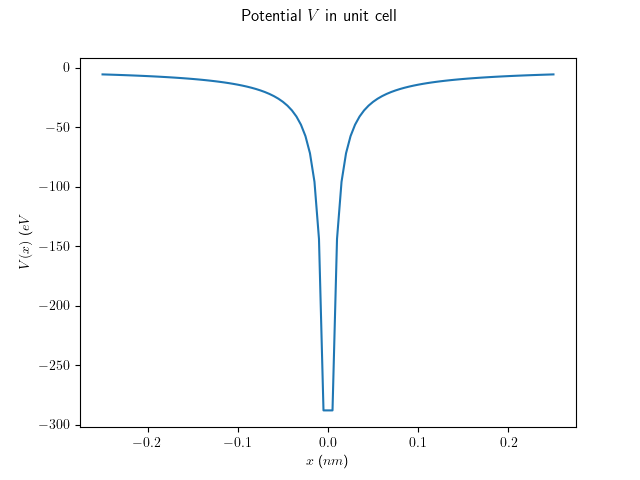

In [18]:
# potential in unit cell
V = lambda x: -e / (4*np.pi*eps_0*np.abs(x))
V_unit = V(x_unit)
#V_unit = np.zeros_like(x_unit)
#V_unit[np.abs(x_unit) < 0.1] = -1

V_unit = np.nan_to_num(V_unit, neginf=np.min(V_unit[~np.isneginf(V_unit)]))

# plot potential
fig, ax = plt.subplots()
ax.plot(x_unit, V_unit)

fig.suptitle(r'Potential \(V\) in unit cell')
ax.set_xlabel(r'\(x\) (\(nm\))')
ax.set_ylabel(r'\(V(x)\) (\(eV\)')

Text(0, 0.5, '\\(U(G)\\)')

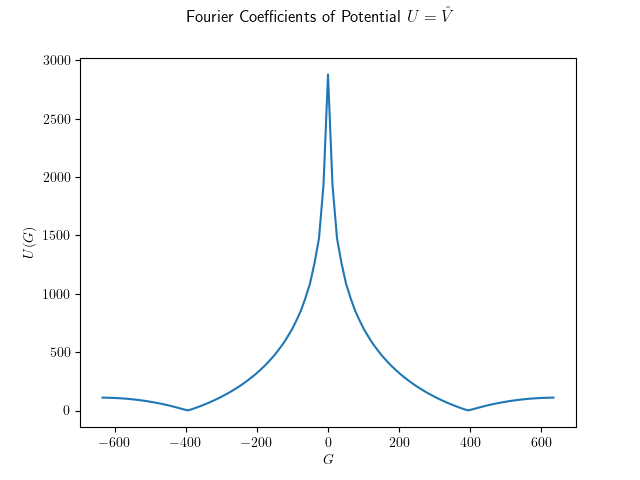

In [19]:
# find fourier coefficients of the potential
U = np.fft.fftshift(np.fft.fft(V_unit))

fig, ax = plt.subplots()
ax.plot(G_set, abs(U)) # shift to avoid line moving back

fig.suptitle(r'Fourier Coefficients of Potential \(U = \hat{V}\)')
ax.set_xlabel(r'\(G\)')
ax.set_ylabel(r'\(U(G)\)')

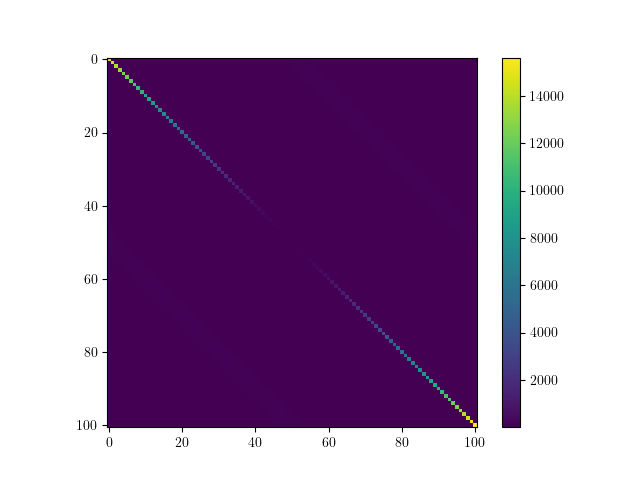

In [20]:
# build system of equations from central equations
def central_equation(k):
    T = h_bar**2/(2*m_e) * (k[:, np.newaxis] - G_set)**2 # in
    return 0.05*scipy.linalg.circulant(U) + np.apply_along_axis(np.diag, 1, T)

A = central_equation(k_set)

# plot single system of equation
fig, ax = plt.subplots()
cm = ax.imshow(np.abs(A[4]))
fig.colorbar(cm)

In [21]:
# find energies and coefficients for all k (shape (k, n))
E, C = np.linalg.eigh(A)

# sort energies
perm = np.argsort(np.mean(E, axis=0))
E = E[:, perm]
C = C[:, perm]

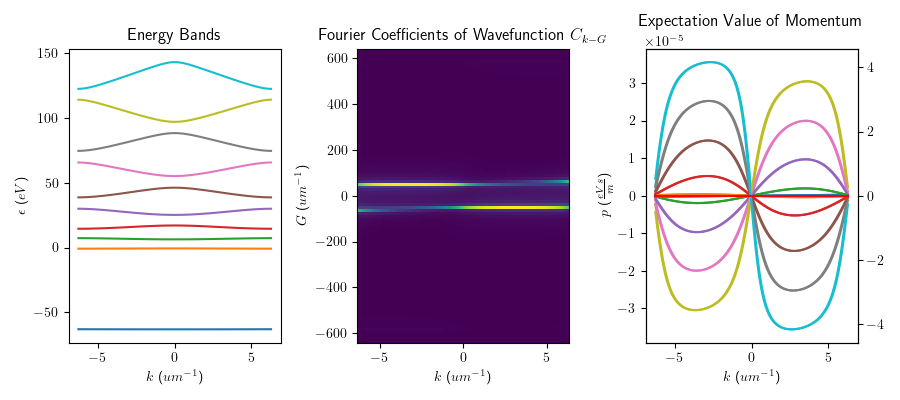

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 4))

# plot energy vs quantum number / (crystal momentum wavenvector) k
ax1.plot(k_set, np.real(E[:, :10]))
ax1.set_title('Energy Bands')
ax1.set_xlabel(r'\(k\) (\(um^{-1}\))')
ax1.set_ylabel(r'\(\epsilon\) (\(eV\))')

# choose energy band
n = 8

# plot the coefficients C[k - G] for different G
ax2.pcolormesh(k_set, G_set, np.abs(C[:, :, n].T))
ax2.set_title(r'Fourier Coefficients of Wavefunction \(C_{k-G}\)')
ax2.set_xlabel(r'\(k\) (\(um^{-1}\))')
ax2.set_ylabel(r'\(G\) (\(um^{-1}\))')

# plot expectation value of the momentum vs quantum number / (crystal momentum wavenvector) k
p_exp = h_bar*np.sum((k_set[:, np.newaxis] - G_set)[:, :, np.newaxis]*np.abs(C)**2, axis=1)

# differentiate energy twice
dk = 2*np.pi/(a*NUM_ATOMS)
dEdk = np.diff(E, axis=0) / dk
dEdkdk = np.diff(dEdk, axis=0) / dk

ax3.plot(k_set, p_exp[:, :10])
ax4 = ax3.twinx()
ax4.plot(k_set[:-1], dEdk[:, :10])
ax4.plot(k_set, h_bar*k_set, color='red')
ax3.set_title('Expectation Value of Momentum')
ax3.set_xlabel(r'\(k\) (\(um^{-1}\))')
ax3.set_ylabel(r'\(p\) (\(\frac{eVs}{m}\))')

fig.tight_layout()

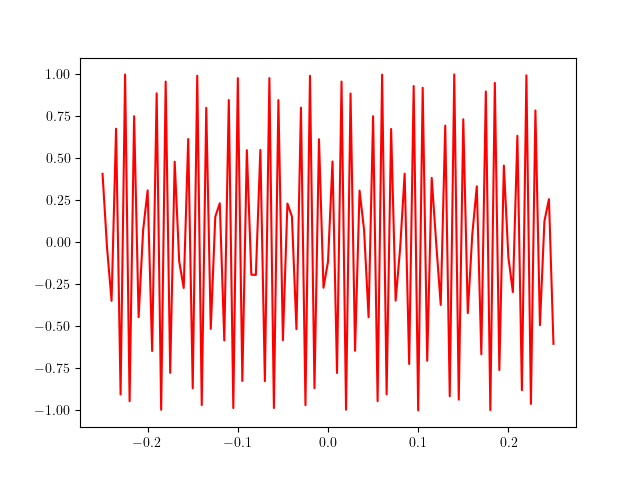

In [16]:
# construct wavefunctions
def psi(x, k_n, n_n):
    return np.sum(C[k_n, n_n] * np.exp(np.outer(x, 1.0j*(k_set[k_n]-G_set))), axis=1)

fig, ax = plt.subplots()
ax.plot(x_unit, np.real(psi(x_unit, 10, 3)), color='red')
#ax.plot(x, np.imag(psi(x, 0, 0)), color='blue')
#ax.plot(x, np.abs(psi(x, 0, 0)), color='black')